## Material Data
Redefined Magnetic Performance Factor Considering Dielectric Effects in Ferrite Cores

In [3]:
%load_ext autoreload
%autoreload 2
"""Example file to show how to get different material data."""
import logging

import materialdatabase as mdb
import numpy as np
from dimensional_performance_factor.meta import paths
from materialdatabase.processing.utils.constants import epsilon_0, mu_0

# configure logging to show femmt terminal output
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.WARNING)

# Plot settings
plot = True
path2grid_plot = paths.grafics

# Save settings
save_to_file = True
path2grid_export = paths.material_data

# init a material database instance
mdb_data = mdb.Data()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
print(f"Path to grid export: {path2grid_export}")

Path to grid export: N:\groups\lea\data\Employees\tpiepe\data_frame\material_data


### N49

INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\N49.csvfor the probe codes ['AT1', 'AT2'].
INFO:Fit parameters for losses: [1.39697210e+00 2.63104891e+00 1.55507994e+01 1.71018179e-20
 3.34881812e+00 5.16872988e+00 9.30242520e-02 1.00432896e-03]
INFO:MRE for loss fit = 0.052413778153150965
INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\N49.csvfor the probe codes ['AC1', 'AC2'].
   189795.91836735  212244.89795918  234693.87755102  257142.85714286
   279591.83673469  302040.81632653  324489.79591837  346938.7755102
   369387.75510204  391836.73469388  414285.71428571  436734.69387755
   459183.67346939  481632.65306122  504081.63265306  526530.6122449
   548979.59183673  571428.57142857  593877.55102041  616326.53061224
   638775.51020408  661224.48979592  683673.46938776  706122.44897959
   728571.42857143  751020.40816327  773469.3877551 

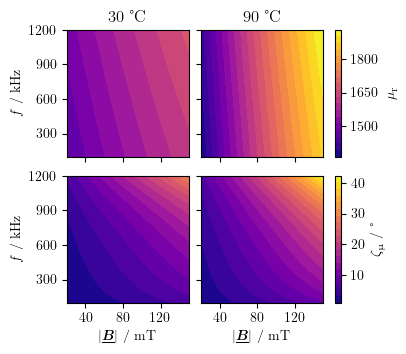

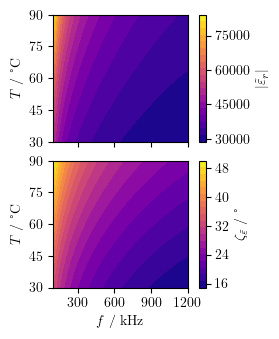

In [5]:
material_name = mdb.Material.N49
permeability_data_source = mdb.DataSource.LEA_MTB
# permeability_probe_codes = None
permeability_probe_codes = ["AT1", "AT2"]
permittivity_data_source = mdb.DataSource.LEA_MTB
permittivity_probe_codes = ["AC1", "AC2"]

# set limits to restrict the used fit data
f_min = 100e3
f_max = 1.2e6

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=permeability_probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 90, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source,
                                                 probe_codes=permittivity_probe_codes)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 90, 20),
                                            f_min_measurement=f_min*0.8,
                                            f_max_measurement=f_max*1.2,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 90],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    # print(f"Data exported to {path2grid_export}")

f_lin = [1e5, 5e5, 1e6]
for f in f_lin:
    # get linearized material data of N49 at 1 MHz, 60 C, 50 mT
    [mu_real], [mu_imag] = permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f, T_op=60, b_vals=np.array([50e-3]))
    eps_real, eps_imag = permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=60)

    # as complex numbers
    mu_N49_lin = mu_real - 1j * mu_imag
    eps_N49_lin = eps_real - 1j * eps_imag

    # wavelength
    k_ = 2 * np.pi * f * np.sqrt(mu_N49_lin * mu_0 * eps_N49_lin * epsilon_0)
    wavelength = 2 * np.pi / k_.real


    # print real and imaginary parts
    # print(f" - - - - - - - - - - - - - - -")
    # print(f"{f = :.1f}")
    # print(f"half wavelength: {wavelength / 2 * 1000:.1f} mm\n")

    # print(f"mu_N49_lin real part: {mu_N49_lin.real:.0f}")
    # print(f"mu_N49_lin imaginary part (positive loss form): {-mu_N49_lin.imag:.0f}\n")

    # print(f"eps_N49_lin real part: {eps_N49_lin.real:.0f}")
    # print(f"eps_N49_lin imaginary part (positive loss form): {-eps_N49_lin.imag:.0f}\n")

    # print(f"|mu_N49_lin|: {abs(mu_N49_lin):.0f}")
    # print(f"phase(mu_N49_lin) in deg (positive loss form): {-np.rad2deg(np.arctan(mu_N49_lin.imag / mu_N49_lin.real)):.1f}\n")

    # print(f"|eps_N49_lin|: {abs(eps_N49_lin):.0f}")
    # print(f"phase(eps_N49_lin) in deg (positive loss form): {-np.rad2deg(np.arctan(eps_N49_lin.imag / eps_N49_lin.real)):.1f}\n")


### N95

INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\N95.csvfor the probe codes ['R29.5x19x14.9'].
INFO:Fit parameters for losses: [1.14887153e+00 2.20898164e+00 7.93901943e+01 3.55908476e-05
 1.07389493e+00 1.86064124e+01 5.20346179e-01 4.12811303e-03]
INFO:MRE for loss fit = 0.06567794754189317
INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\N95.csv.
  153061.2244898  166326.53061224 179591.83673469 192857.14285714
  206122.44897959 219387.75510204 232653.06122449 245918.36734694
  259183.67346939 272448.97959184 285714.28571429 298979.59183673
  312244.89795918 325510.20408163 338775.51020408 352040.81632653
  365306.12244898 378571.42857143 391836.73469388 405102.04081633
  418367.34693878 431632.65306122 444897.95918367 458163.26530612
  471428.57142857 484693.87755102 497959.18367347 511224.48979592
  524489.79591837 537755.10204082 551020

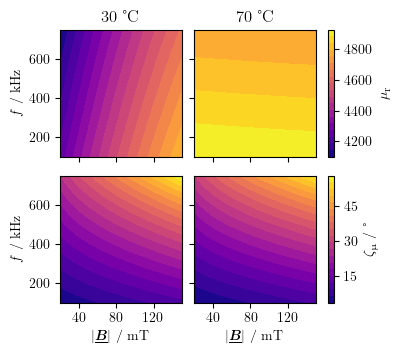

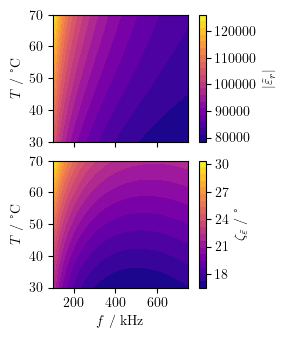

In [6]:
material_name = mdb.Material.N95
probe_codes = ["R29.5x19x14.9"]
permeability_data_source = mdb.DataSource.LEA_MTB
permittivity_data_source = mdb.DataSource.LEA_MTB

# set limits to restrict the used fit data
f_min = 100e3
f_max = 750e3

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            f_min_measurement=f_min,
                                            f_max_measurement=f_max,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 70],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    # print(f"Data exported to {path2grid_export}")

INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\3F46.csvfor the probe codes ['R25x15x10'].
INFO:Fit parameters for losses: [ 1.00455582e+00  2.13015920e+00  1.72172703e+03  5.13709857e-10
  1.84512608e+00 -2.27161166e+01 -2.06648670e-01  6.47772206e-03]
INFO:MRE for loss fit = 0.12006306783064791
INFO:Complex data read from X:\Till_data\repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\3F46.csv.
   255102.04081633  293877.55102041  332653.06122449  371428.57142857
   410204.08163265  448979.59183673  487755.10204082  526530.6122449
   565306.12244898  604081.63265306  642857.14285714  681632.65306122
   720408.16326531  759183.67346939  797959.18367347  836734.69387755
   875510.20408163  914285.71428571  953061.2244898   991836.73469388
  1030612.24489796 1069387.75510204 1108163.26530612 1146938.7755102
  1185714.28571429 1224489.79591837 1263265.30612245 1302040.81632653
  134081

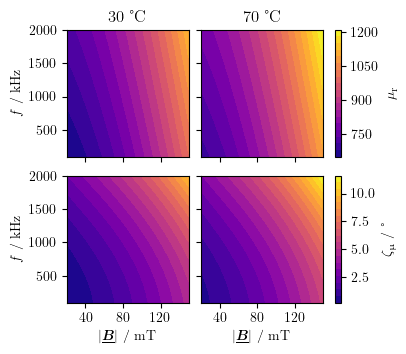

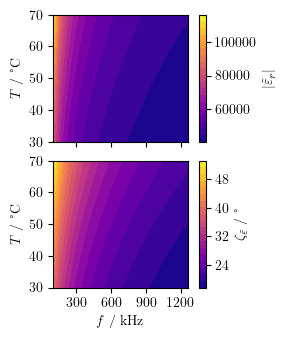

In [7]:
material_name = mdb.Material._3F46
probe_codes = ["R25x15x10"]
permeability_data_source = mdb.DataSource.LEA_MTB
permittivity_data_source = mdb.DataSource.LEA_MTB

# set limits to restrict the used fit data
f_min = 100e3
f_max = 2000e3

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            f_min_measurement=f_min,
                                            f_max_measurement=f_max,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 70],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    # print(f"Data exported to {path2grid_export}")